In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [2]:
import importlib

import src.meshharm 
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

In [3]:
path = 'Data/20260211/'

res = np.load(f'{path}/multi_shape_bof_results_raw_value.npz', allow_pickle=True)
ids = res['filtered_ids']
times = res['filtered_time']
spectrums = res['filtered_spectrums']
areas = res['filtered_areas']
complexities = res['filtered_complexities']

res = np.load('sim/vocab_new.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scaler'].item() 
sigma = res['sigma']
ts = res['ts']

print(spectrums.shape) 

(125, 8, 8)


       label_uid     tsne1     tsne2  complexity
0  day4p5_B02_41  5.849994 -0.086673    5.059532
1   day4p5_B02_7 -2.599388 -9.748991    2.521908
2  day4p5_B02_68  2.872677 -2.132967    5.748591
3   day4p5_B02_6 -1.667203  1.928013    4.226347
4  day4p5_B02_40  3.357883 -3.945885    4.931770
(125, 4)


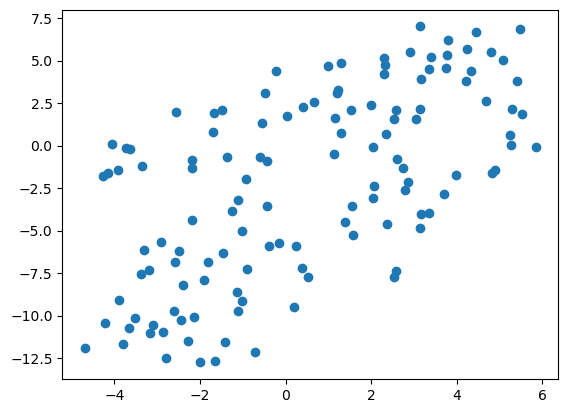

In [4]:
dim_red_results = pd.read_csv(f'{path}/tsne_results_raw_value.csv')
print(dim_red_results.head())
print(dim_red_results.shape)

plt.plot(dim_red_results['tsne1'], dim_red_results['tsne2'], 'o')
plt.show()  

In [15]:
# randomly select organoids of high complexities 
high_complexity_df = dim_red_results[dim_red_results['complexity'] > 5.5]

indices = np.random.choice(high_complexity_df.index, size=5, replace=False)

list_of_ids = high_complexity_df.loc[indices, 'label_uid'].tolist()


In [33]:
list_of_ids = ['day4p5_B05_70', 'day4p5_B04_42']

IndexError: index 0 is out of bounds for axis 0 with size 0

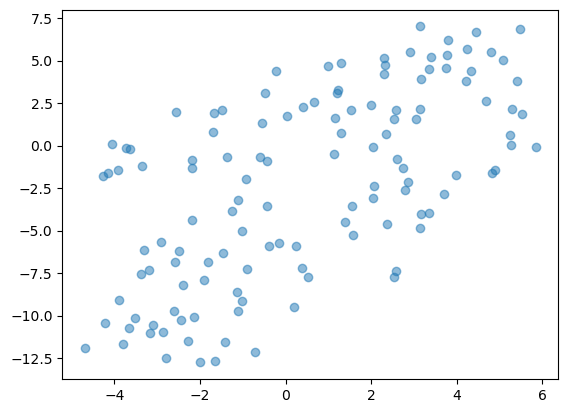

In [34]:
closest_ids = [] 
weights = np.sqrt(np.array([2, 2, 1, 0.1, 1, 2, 0.1, 2])) 
ks = np.ones(spectrums.shape[1])

plt.plot(dim_red_results['tsne1'], dim_red_results['tsne2'], 'o', alpha=0.5)
for i in list_of_ids: 
    # find the organoid that's closest to the selected id in terms of distance in reduced space 
    org_index = dim_red_results[dim_red_results['label_uid'] == i].index[0]
    dists = np.linalg.norm((spectrums - spectrums[org_index][np.newaxis, :, :]) * weights[np.newaxis, np.newaxis, :] * ks[np.newaxis, :, np.newaxis], axis=(1, 2))
    dists[dists == 0]  = np.inf  # exclude itself
    closest_index = np.argmin(dists) 
    closest_id = dim_red_results.loc[closest_index, 'label_uid']
    print(f"Selected organoid ID: {i}, Closest organoid ID: {closest_id}")
    closest_ids.append(closest_id)

    xs = [dim_red_results.loc[org_index, 'tsne1'], dim_red_results.loc[closest_index, 'tsne1']]
    ys = [dim_red_results.loc[org_index, 'tsne2'], dim_red_results.loc[closest_index, 'tsne2']]
    plt.plot(xs, ys, 'o--', alpha=1, label=f"{i}")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show() 


In [32]:
# list_of_ids = ['day4p5-more_C02_34', 'day4p5-more_C03_55']

import json 

with open(f"{path}config.json", 'r') as f:
        cfg = json.load(f)

annotation_names = cfg['annotation_names']
reverse_annotation_names = {v: k for k, v in annotation_names.items()}
round_name = cfg['rounds']['day4p5']
mesh_name = cfg['mesh_name']
zarr_name = cfg['zarr_names']['day4p5']

for (i, id) in enumerate(list_of_ids): 
    print(id)
    label = id.split('_')
    file_path = f'{path}/fractal_output/{label[0]}/{zarr_name}/{label[1][0]}/{label[1][1:]}/{round_name}/meshes/{mesh_name}/{label[2]}.vtp'

    print(file_path) 
    m = FateMarkers()
    m.load_mesh_from_file(file_path) 
    m.align_with_pca()


    lgr5_index = m.field_names.index('0.C02.percentile99_class')
    plot(m.v, m.f, c=m.fields[:, lgr5_index])

    cloest_id = closest_ids[i]
    print(f"Closest organoid ID: {cloest_id}")
    label = cloest_id.split('_')
    file_path = f'{path}/fractal_output/{label[0]}/{zarr_name}/{label[1][0]}/{label[1][1:]}/{round_name}/meshes/{mesh_name}/{label[2]}.vtp'
    m = FateMarkers()
    m.load_mesh_from_file(file_path) 
    m.align_with_pca()

    lgr5_index = m.field_names.index('0.C02.percentile99_class')
    plot(m.v, m.f, c=m.fields[:, lgr5_index])

day4p5_B04_9
Data/20260211//fractal_output/day4p5/251130R0.zarr/B/04/2_zillum_registered/meshes/nnorg_corrected_smoothed_annotated_by_projection/9.vtp


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.282042…

Closest organoid ID: day4p5_B03_91


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1784744…

day4p5_B03_87
Data/20260211//fractal_output/day4p5/251130R0.zarr/B/03/2_zillum_registered/meshes/nnorg_corrected_smoothed_annotated_by_projection/87.vtp


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.301342…

day4p5_B02_22
Data/20260211//fractal_output/day4p5/251130R0.zarr/B/02/2_zillum_registered/meshes/nnorg_corrected_smoothed_annotated_by_projection/22.vtp


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1799774…

Closest organoid ID: day4p5_B05_28


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.3391268…